=== INICIALIZANDO INTERPRETACIÓN BAYESIANA ACMG/AMP ===
Nota: El nombre que ingrese para cada criterio será el que aparecerá junto al punto en el gráfico.

--------------------------------------------------
Niveles disponibles: supp (Supporting), mod (Moderate), str (Strong), vstr (Very Strong)
-> Evidencia agregada: PM2_Supp | Probabilidad Post_P actual: 0.188

--------------------------------------------------

Generando gráfico de progresión clínica...


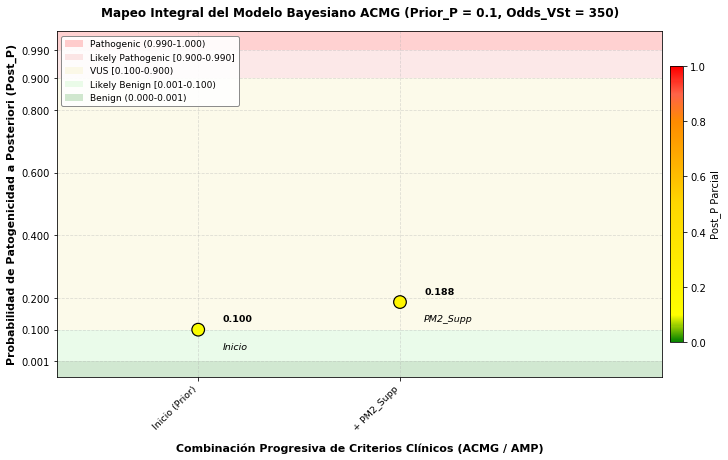

In [1]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import numpy as np


class ACMGPlotter:

    def __init__(self, prior_p=0.10, odds_vst=350.0):
        self.prior_p = prior_p
        self.odds_vst = odds_vst

        self.weights = {
            'PVS': 1.0,
            'PS': 0.5,
            'PM': 0.25,
            'PP': 0.125,
            'BVS': -1.0,
            'BS': -0.5,
            'BM': -0.25,
            'BP': -0.125,
        }

        self.counts = {
            'PVS': 0,
            'PS': 0,
            'PM': 0,
            'PP': 0,
            'BVS': 0,
            'BS': 0,
            'BM': 0,
            'BP': 0,
            'BA1': 0,
        }

        self.point_labels = ['Inicio']
        self.xaxis_labels = ['Inicio (Prior)']
        self.values = [self.prior_p]

    def calculate_post_p(self):
        if self.counts['BA1'] > 0:
            return 0.0

        exponent = sum(
            self.counts[k] * self.weights[k] for k in self.weights.keys()
        )
        op = self.odds_vst**exponent

        post_p = (op * self.prior_p) / ((op - 1) * self.prior_p + 1)
        return round(float(post_p), 3)

    def add_evidence(self, code_name, direction, strength):
        code_upper = code_name.strip().upper()

        if code_upper == 'BA1':
            self.counts['BA1'] += 1
            label_text = 'BA1'
        else:
            if direction.lower().startswith('p'):
                prefix_map = {
                    'vstr': 'PVS',
                    'str': 'PS',
                    'mod': 'PM',
                    'supp': 'PP',
                }
                prefix = prefix_map.get(strength.lower(), 'PP')
            else:
                prefix_map = {
                    'vstr': 'BVS',
                    'str': 'BS',
                    'mod': 'BM',
                    'supp': 'BP',
                }
                prefix = prefix_map.get(strength.lower(), 'BP')

            self.counts[prefix] += 1
            label_text = code_name.strip()

        post_p = self.calculate_post_p()

        self.point_labels.append(label_text)
        self.xaxis_labels.append(f'+ {label_text}')
        self.values.append(post_p)

        print(
            f'-> Evidencia agregada: {label_text} | Probabilidad Post_P actual: {post_p:.3f}'
        )

    def plot(self):
        # 1. Configuración de la figura
        fig, ax = plt.subplots(figsize=(11, 6.5))

        # 2. Fondos coloreados según rangos ACMG
        ax.axhspan(
            0.99, 1.05, facecolor='red', alpha=0.18, label='Pathogenic (0.990-1.000)'
        )
        ax.axhspan(
            0.90,
            0.99,
            facecolor='lightcoral',
            alpha=0.18,
            label='Likely Pathogenic [0.900-0.990]',
        )
        ax.axhspan(
            0.10, 0.90, facecolor='khaki', alpha=0.18, label='VUS [0.100-0.900)'
        )
        ax.axhspan(
            0.001,
            0.10,
            facecolor='lightgreen',
            alpha=0.18,
            label='Likely Benign [0.001-0.100)',
        )
        ax.axhspan(
            -0.05, 0.001, facecolor='green', alpha=0.18, label='Benign (0.000-0.001)'
        )

        indices = np.arange(len(self.values))

        # 3. Colormap calibrado
        color_positions = [0.0, 0.1, 0.5, 0.8, 0.9, 1.0]
        color_tones = [
            'green',
            'yellow',
            'gold',
            'darkorange',
            'tomato',
            'red',
        ]
        custom_cmap = LinearSegmentedColormap.from_list(
            'acmg_calibrated', list(zip(color_positions, color_tones)), N=256
        )

        # 4. Puntos de dispersión
        scatter = ax.scatter(
            indices,
            self.values,
            c=self.values,
            cmap=custom_cmap,
            marker='o',
            s=160,
            vmin=0,
            vmax=1,
            zorder=5,
            edgecolors='black',
            linewidths=1.2,
        )

        # 5. Ajuste de ejes (se remueve 1.0 del YTick para evitar superposición con 0.99)
        ax.set_xlim(-0.7, len(self.values) + 0.3)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(indices)
        ax.set_xticklabels(
            self.xaxis_labels,
            rotation=45,
            ha='right',
            fontsize=9.5,
            fontweight='medium',
        )
        ax.set_yticks([0.001, 0.1, 0.2, 0.4, 0.6, 0.8, 0.9, 0.99])

        # 6. Inserción de etiquetas a la derecha de cada punto
        for i, val, text in zip(indices, self.values, self.point_labels):
            ax.text(
                i + 0.12,
                val + 0.02,
                f'{val:.3f}',
                ha='left',
                va='bottom',
                fontsize=9.5,
                weight='bold',
                zorder=6,
            )
            ax.text(
                i + 0.12,
                val - 0.04,
                text,
                ha='left',
                va='top',
                fontsize=9.5,
                style='italic',
                zorder=6,
            )

        # 7. Barra de color y detalles finales
        cbar = fig.colorbar(
            scatter, ax=ax, orientation='vertical', pad=0.01, shrink=0.8
        )
        cbar.set_label('Post_P Parcial', fontsize=10, fontweight='medium')

        ax.set_xlabel(
            'Combinación Progresiva de Criterios Clínicos (ACMG / AMP)',
            fontsize=11,
            fontweight='bold',
            labelpad=10,
        )
        ax.set_ylabel(
            'Probabilidad de Patogenicidad a Posteriori (Post_P)',
            fontsize=11,
            fontweight='bold',
        )
        ax.set_title(
            f'Mapeo Integral del Modelo Bayesiano ACMG (Prior_P = {self.prior_p}, Odds_VSt = {self.odds_vst})',
            fontsize=12,
            fontweight='bold',
            pad=15,
        )
        ax.grid(axis='both', linestyle='--', alpha=0.4, zorder=1)
        ax.legend(
            loc='upper left',
            fontsize=9,
            framealpha=0.9,
            facecolor='white',
            edgecolor='gray',
        )

        plt.tight_layout()
        plt.show()


def run_acmg_interactive():
    print('=== INICIALIZANDO INTERPRETACIÓN BAYESIANA ACMG/AMP ===')
    print(
        'Nota: El nombre que ingrese para cada criterio será el que aparecerá junto al punto en el gráfico.'
    )
    plotter = ACMGPlotter(prior_p=0.10, odds_vst=350)

    while True:
        print('\n' + '-' * 50)
        code_name = input(
            "Ingrese el nombre de la etiqueta (ej. PM2_Supp, PP3) o 'FIN' para graficar: "
        )

        if code_name.strip().upper() == 'FIN':
            break

        if not code_name.strip():
            continue

        if code_name.strip().upper() == 'BA1':
            plotter.add_evidence('BA1', direction='b', strength='vstr')
            continue

        direction = input(
            '¿La evidencia es Patogénica o Benigna? [P/B]: '
        ).strip()
        print(
            'Niveles disponibles: supp (Supporting), mod (Moderate), str'
            ' (Strong), vstr (Very Strong)'
        )
        strength = input(
            'Ingrese el nivel de fuerza [supp/mod/str/vstr]: '
        ).strip()

        plotter.add_evidence(code_name, direction, strength)

    print('\nGenerando gráfico de progresión clínica...')
    plotter.plot()


# Ejecutar asistente interactivo
run_acmg_interactive()